In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from torch.utils.tensorboard import SummaryWriter
import joblib
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [133]:
def load_preprocessed_data():
    """Load preprocessed data from Step 2"""
    
    # Load data
    data = np.load('data/processed/all_tickers_preprocessed_final.npz')
    
    # Load scaler
    scaler = joblib.load('data/processed/all_tickers_scaler_final.pkl')
    
    # Load metadata
    metadata = joblib.load('data/processed/all_tickers_metadata_final.pkl')
    
    return {
        'X_train': data['X_train'],
        'X_val': data['X_val'],
        'X_test': data['X_test'],
        'y_train_reg': data['y_train_reg'],
        'y_val_reg': data['y_val_reg'],
        'y_test_reg': data['y_test_reg'],
        'y_train_cls': data['y_train_cls'],
        'y_val_cls': data['y_val_cls'],
        'y_test_cls': data['y_test_cls'],
        'scaler': scaler,
        'feature_cols': metadata['feature_cols'],
        'metadata': metadata
    }

# Load data
data_loaded = load_preprocessed_data()

X_train = data_loaded['X_train']
X_val = data_loaded['X_val']
X_test = data_loaded['X_test']
y_train = data_loaded['y_train_reg']
y_val = data_loaded['y_val_reg']
y_test = data_loaded['y_test_reg']
feature_cols = data_loaded['feature_cols']

print(f"✅ Data loaded successfully!")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_val shape: {X_val.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  Features: {feature_cols}")
print(f"  Train samples: {len(y_train):,}")
print(f"  Val samples: {len(y_val):,}")
print(f"  Test samples: {len(y_test):,}")

✅ Data loaded successfully!
  X_train shape: (180132, 8)
  X_val shape: (38596, 8)
  X_test shape: (38645, 8)
  Features: ['RSI_14', 'MACD_line', 'MACD_signal', 'MACD_histogram', 'BB_width', 'ATR_14', 'OBV', 'MA_Crossover_5_20']
  Train samples: 180,132
  Val samples: 38,596
  Test samples: 38,645


In [135]:
class StockDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.FloatTensor(features)
        self.y = torch.FloatTensor(targets)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train, y_train_reg)
val_dataset = StockDataset(X_val, y_val_reg)
test_dataset = StockDataset(X_test, y_test_reg)

In [137]:
input_dim = X_train.shape[1]

class StockPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate=0.3):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)

model = StockPredictor(input_dim=input_dim, hidden_dims=(128, 64, 32), dropout_rate=0.3)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


In [139]:
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [141]:
# Check train
for X, y in train_loader:
    print(f"  Train - X mean: {X.mean():.6f}, std: {X.std():.6f}")
    break

# Check val
for X, y in val_loader:
    print(f"  Val   - X mean: {X.mean():.6f}, std: {X.std():.6f}")
    break

# Check test
for X, y in test_loader:
    print(f"  Test  - X mean: {X.mean():.6f}, std: {X.std():.6f}")
    break

print("\n" + "="*60)
print("✅ DATA IS NOW PROPERLY SCALED!")
print("="*60)

  Train - X mean: 0.029026, std: 0.939387
  Val   - X mean: 1.042989, std: 1.375656
  Test  - X mean: 0.731510, std: 2.418939

✅ DATA IS NOW PROPERLY SCALED!


In [143]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    n_batches = 0
    
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        n_batches += 1
    
    return total_loss / n_batches

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item()
            
            correct += ((preds > 0) == (y_batch > 0)).sum().item()
            total += len(y_batch)
            
            predictions.extend(preds.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    
    return total_loss / len(loader), correct / total, np.array(predictions), np.array(actuals)
    
def train_model(
    model, train_loader, val_loader, criterion, optimizer,
    device, max_epochs=100, patience=10, verbose=True, writer=None, arch_name=''):
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    val_accs = []
    
    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validate
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                val_loss += loss.item()
                
                correct += ((predictions > 0) == (y_batch > 0)).sum().item()
                total += len(y_batch)
        
        val_loss /= len(val_loader)
        val_acc = correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        if writer:
            writer.add_scalar(f'Loss/{arch_name}/Train', train_loss, epoch)
            writer.add_scalar(f'Loss/{arch_name}/Validation', val_loss, epoch)
            writer.add_scalar(f'Accuracy/{arch_name}', val_acc, epoch)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = " ★"
        else:
            patience_counter += 1
            marker = ""
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{max_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Acc: {val_acc:.2%}{marker}")
        
        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_model_state:
        model.load_state_dict(best_model_state)
        if verbose:
            print(f"Restored best model (val_loss: {best_val_loss:.6f})")
    
    return model, train_losses, val_losses, val_accs

In [147]:
model = StockPredictor(
    input_dim=X_train.shape[1],
    hidden_dims=[128, 64],
    dropout_rate=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Train using your function
model, train_losses, val_losses, val_accs = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    max_epochs=100,
    patience=10,
    verbose=True,
    writer=None,
    arch_name='FeedforwardNN'
)


Epoch  10/100 | Train Loss: 0.000384 | Val Loss: 0.000535 | Acc: 48.28%
Early stopping at epoch 16
Restored best model (val_loss: 0.000533)


In [155]:
criterion = nn.MSELoss()
test_loss, test_acc, test_preds, test_targets = evaluate(
    model, test_loader, criterion, device
)

print(f"Test MSE:  {test_loss:.6f}")
print(f"Test MAE:  {mean_absolute_error(test_targets, test_preds):.6f}")
print(f"Test Directional Accuracy: {test_acc:.2%}")

strategy_returns = np.where(test_preds > 0, test_targets, 0)
sharpe_ratio = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252) if strategy_returns.std() > 0 else 0

print(f"Strategy Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"Number of trades: {np.sum(test_preds > 0)}")

Test MSE:  0.000298
Test MAE:  0.011640
Test Directional Accuracy: 52.73%
Strategy Sharpe Ratio: 0.5919
Number of trades: 38645


In [157]:
lr = LinearRegression()
lr.fit(X_train, y_train_reg)

lr_preds = lr.predict(X_test)
lr_mse = mean_squared_error(y_test_reg, lr_preds)
lr_mae = mean_absolute_error(y_test_reg, lr_preds)
lr_acc = np.mean((lr_preds > 0) == (y_test_reg > 0))

print(f"Linear Regression:")
print(f"  MSE: {lr_mse:.6f}")
print(f"  MAE: {lr_mae:.6f}")
print(f"  Directional Accuracy: {lr_acc:.2%}")

print(f"{'Metric':<25} {'Neural Network':<20} {'Linear Regression':<20} {'Improvement':<15}")
print("-"*80)
print(f"{'MSE':<25} {test_loss:<20.6f} {lr_mse:<20.6f} {test_loss - lr_mse:<+15.6f}")
print(f"{'MAE':<25} {mean_absolute_error(test_targets, test_preds):<20.6f} {lr_mae:<20.6f} {mean_absolute_error(test_targets, test_preds) - lr_mae:<+15.6f}")
print(f"{'Directional Accuracy':<25} {test_acc:<20.2%} {lr_acc:<20.2%} {test_acc - lr_acc:<+15.2%}")

Linear Regression:
  MSE: 0.000303
  MAE: 0.011812
  Directional Accuracy: 50.03%
Metric                    Neural Network       Linear Regression    Improvement    
--------------------------------------------------------------------------------
MSE                       0.000298             0.000303             -0.000005      
MAE                       0.011640             0.011812             -0.000171      
Directional Accuracy      52.73%               50.03%               +2.70%         


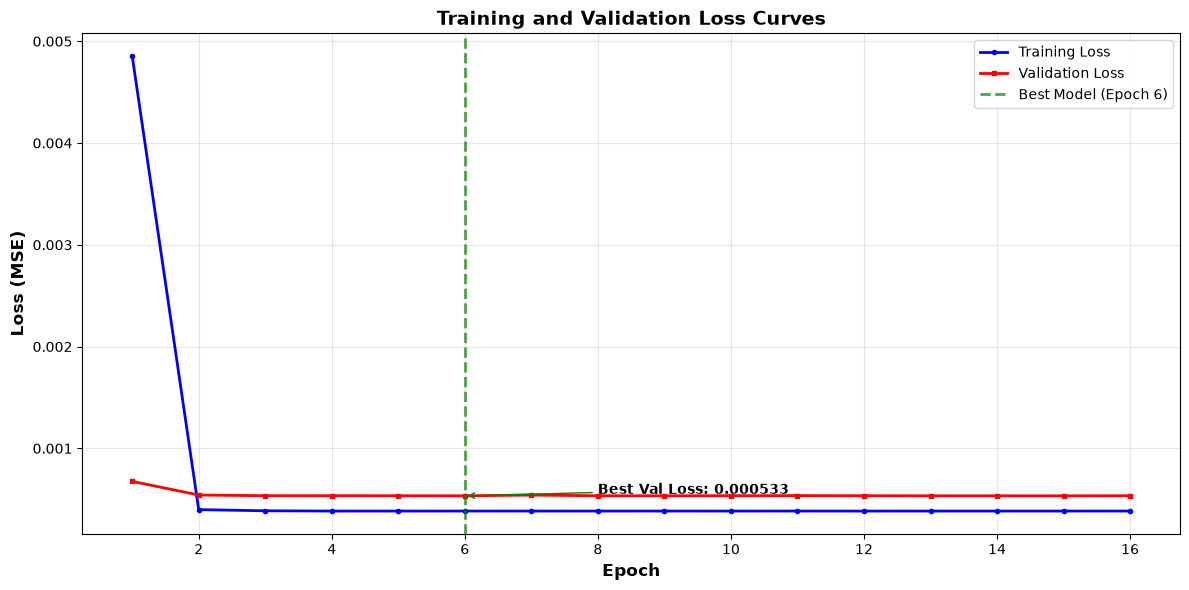


✅ Corrected loss curves saved to: loss_curves_correct.png
   Best model at epoch: 6
   Best validation loss: 0.000533


In [153]:
fig, ax = plt.subplots(figsize=(12, 6))

epochs = range(1, len(train_losses) + 1)

ax.plot(epochs, train_losses, label='Training Loss', 
        color='blue', linewidth=2, marker='o', markersize=3)

ax.plot(epochs, val_losses, label='Validation Loss', 
        color='red', linewidth=2, marker='s', markersize=3)

best_epoch = np.argmin(val_losses)
best_loss = val_losses[best_epoch]

ax.axvline(x=best_epoch + 1, color='green', linestyle='--', 
           linewidth=2, alpha=0.7, label=f'Best Model (Epoch {best_epoch+1})')

ax.annotate(f'Best Val Loss: {best_loss:.6f}', 
            xy=(best_epoch + 1, best_loss),
            xytext=(best_epoch + 3, best_loss + 0.00002),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, fontweight='bold')

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
ax.set_title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')

ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('loss_curves_correct.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


print("\n✅ Corrected loss curves saved to: loss_curves_correct.png")
print(f"   Best model at epoch: {best_epoch+1}")
print(f"   Best validation loss: {best_loss:.6f}")

Parameters: 9,857
Epoch  10/100 | Train Loss: 0.000384 | Val Loss: 0.000534 | Acc: 48.28%
Epoch  20/100 | Train Loss: 0.000384 | Val Loss: 0.000534 | Acc: 51.72%
Epoch  30/100 | Train Loss: 0.000384 | Val Loss: 0.000534 | Acc: 51.72%
Early stopping at epoch 36
Restored best model (val_loss: 0.000533)
Parameters: 11,969
Epoch  10/100 | Train Loss: 0.000384 | Val Loss: 0.000534 | Acc: 51.72%
Early stopping at epoch 17
Restored best model (val_loss: 0.000533)
Parameters: 23,041
Epoch  10/100 | Train Loss: 0.000384 | Val Loss: 0.000534 | Acc: 48.28%
Early stopping at epoch 19
Restored best model (val_loss: 0.000533)

Architecture         Hidden Layers  Parameters  Best Val Loss  Best Epoch  Test MSE  Test Accuracy  Sharpe Ratio
     2-Layer             [128, 64]        9857       0.000533          26  0.000298       0.527313      0.591887
     3-Layer         [128, 64, 32]       11969       0.000533           7  0.000298       0.527313      0.591887
     5-Layer [128, 96, 64, 32, 16]      

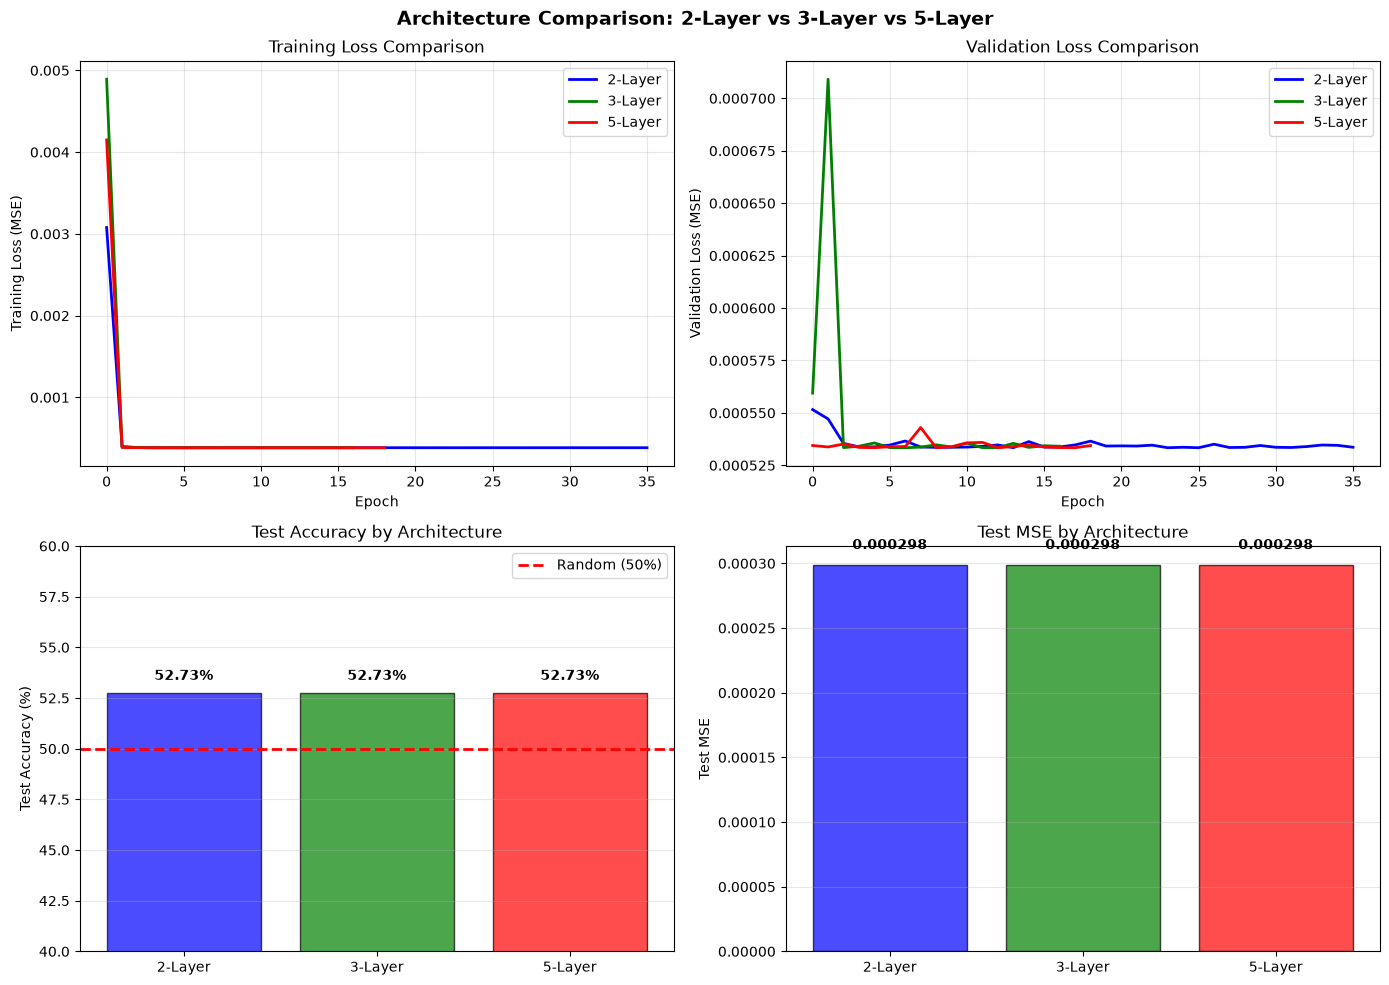

In [159]:
architectures = {
    '2-Layer': [128, 64],
    '3-Layer': [128, 64, 32],
    '5-Layer': [128, 96, 64, 32, 16]
}

architecture_results = {}

for arch_name, hidden_dims in architectures.items():
    model_arch = StockPredictor(
        input_dim=len(feature_cols),
        hidden_dims=hidden_dims,
        dropout_rate=0.3
    ).to(device)
    
    n_params = sum(p.numel() for p in model_arch.parameters() if p.requires_grad)
    print(f"Parameters: {n_params:,}")
    
    optimizer_arch = torch.optim.Adam(
        model_arch.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )
    criterion = nn.MSELoss()
    
    trained_model, train_losses_arch, val_losses_arch, val_accs_arch = train_model(
        model_arch, train_loader, val_loader, criterion, optimizer_arch,
        device, max_epochs=100, patience=10, verbose=True
    )
    
    test_loss_arch, test_acc_arch, test_preds_arch, test_targets_arch = evaluate(
        trained_model, test_loader, criterion, device
    )
    
    strategy_returns = np.where(test_preds_arch > 0, test_targets_arch, 0)
    sharpe_ratio_arch = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252) if strategy_returns.std() > 0 else 0
    
    architecture_results[arch_name] = {
        'hidden_dims': hidden_dims,
        'n_params': n_params,
        'train_losses': train_losses_arch,
        'val_losses': val_losses_arch,
        'best_val_loss': min(val_losses_arch),
        'best_epoch': np.argmin(val_losses_arch) + 1,
        'test_loss': test_loss_arch,
        'test_acc': test_acc_arch,
        'sharpe_ratio': sharpe_ratio_arch
    }

comparison_df = pd.DataFrame({
    'Architecture': list(architecture_results.keys()),
    'Hidden Layers': [str(r['hidden_dims']) for r in architecture_results.values()],
    'Parameters': [r['n_params'] for r in architecture_results.values()],
    'Best Val Loss': [r['best_val_loss'] for r in architecture_results.values()],
    'Best Epoch': [r['best_epoch'] for r in architecture_results.values()],
    'Test MSE': [r['test_loss'] for r in architecture_results.values()],
    'Test Accuracy': [r['test_acc'] for r in architecture_results.values()],
    'Sharpe Ratio': [r['sharpe_ratio'] for r in architecture_results.values()]
})

print("\n" + comparison_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Architecture Comparison: 2-Layer vs 3-Layer vs 5-Layer', 
             fontsize=14, fontweight='bold')

colors = {'2-Layer': 'blue', '3-Layer': 'green', '5-Layer': 'red'}

for arch_name, results in architecture_results.items():
    axes[0, 0].plot(results['train_losses'], label=f'{arch_name}', 
                    color=colors[arch_name], linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss (MSE)')
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for arch_name, results in architecture_results.items():
    axes[0, 1].plot(results['val_losses'], label=f'{arch_name}', 
                    color=colors[arch_name], linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Loss (MSE)')
axes[0, 1].set_title('Validation Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

bars1 = axes[1, 0].bar(comparison_df['Architecture'], 
                       comparison_df['Test Accuracy'] * 100,
                       color=['blue', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=50, color='red', linestyle='--', label='Random (50%)', linewidth=2)
axes[1, 0].set_ylabel('Test Accuracy (%)')
axes[1, 0].set_title('Test Accuracy by Architecture')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_ylim(40, 60)

for bar, acc in zip(bars1, comparison_df['Test Accuracy']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1, 1].bar(comparison_df['Architecture'], 
                       comparison_df['Test MSE'],
                       color=['blue', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Test MSE')
axes[1, 1].set_title('Test MSE by Architecture')
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar, mse in zip(bars2, comparison_df['Test MSE']):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00001,
                    f'{mse:.6f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

